\newpage

In [108]:
# Import Necessary Libraries
from ucimlrepo import fetch_ucirepo 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn import neighbors, metrics
from sklearn.preprocessing import scale
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score

In [109]:
# Import the Required Dataset
url = 'https://raw.githubusercontent.com/PratheepaJ/datasets/refs/heads/master/ass6-dataset.csv'
df = pd.read_csv(url)
y = df['num']

(1)
The response variable is num, which represents the presence or absence of heart disease. For classification purposes, this variable will be transformed into a binary format, 
where: 0 indicates no presence of heart disease and 1 indicates presence of heart disease

This forms the basis of a binary classification problem. The objective is to use the available features to predict whether a patient has heart disease or not. Successfully solving this classification problem can aid in early detection and timely medical intervention for heart disease.

\newpage

In [110]:
(2)
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
num           int64
dtype: object

1. The "Variable Table" on the UCI website shows that certain variables like 'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal' are categorical, but the above output shows they are in the integer form. So there is a need to transform them into categorical.  
2. We also scaled the numerical variables so they contribute equally in the data science methods we performed later in this assignment.

In [111]:
# Transform the categorical type variables in the 'Variable Table' to categorical
cg_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
for col in cg_cols:
    df[col] = df[col].astype('category')

# Transform the target variable into Categorical
df['num'] = pd.Categorical(df['num'])



In [112]:
# Scale the numerical variables 
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

\newpage

In [113]:
(3)
# Dimensions
df.shape

(303, 14)

The dataset contains 303 observations and 14 features.

In [114]:
# Variable types and Summaries
print(df.dtypes)
df.describe(include='all')


age          float64
sex         category
cp          category
trestbps     float64
chol         float64
fbs         category
restecg     category
thalach      float64
exang       category
oldpeak      float64
slope       category
ca          category
thal        category
num         category
dtype: object


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
count,3.030000e+02,303.0,303.0,3.030000e+02,3.030000e+02,303.0,303.0,3.030000e+02,303.0,3.030000e+02,303.0,299.0,301.0,303.0
unique,NaN,2.0,4.0,NaN,NaN,2.0,3.0,NaN,2.0,NaN,3.0,4.0,3.0,5.0
top,NaN,1.0,4.0,NaN,NaN,0.0,0.0,NaN,0.0,NaN,1.0,0.0,3.0,0.0
freq,NaN,206.0,144.0,NaN,NaN,258.0,151.0,NaN,204.0,NaN,142.0,176.0,166.0,164.0
mean,-1.465641e-18,NaN,NaN,4.426236e-16,2.345026e-16,NaN,NaN,-1.172513e-16,NaN,2.345026e-17,NaN,NaN,NaN,NaN
std,1.001654e+00,NaN,NaN,1.001654e+00,1.001654e+00,NaN,NaN,1.001654e+00,NaN,1.001654e+00,NaN,NaN,NaN,NaN
min,-2.819115e+00,NaN,NaN,-2.145037e+00,-2.334877e+00,NaN,NaN,-3.442067e+00,NaN,-8.968617e-01,NaN,NaN,NaN,NaN
25%,-7.135564e-01,NaN,NaN,-6.652997e-01,-6.905030e-01,NaN,NaN,-7.053073e-01,NaN,-8.968617e-01,NaN,NaN,NaN,NaN
50%,1.729945e-01,NaN,NaN,-9.616980e-02,-1.101357e-01,NaN,NaN,1.485618e-01,NaN,-2.067053e-01,NaN,NaN,NaN,NaN
75%,7.270888e-01,NaN,NaN,4.729601e-01,5.476139e-01,NaN,NaN,7.178079e-01,NaN,4.834512e-01,NaN,NaN,NaN,NaN


Most variables are numeric, but several features such as cp, thal, and slope represent categorical concepts and were converted to the 'category' dtype in question 2.
According to the summary, the maximum number of age is 77, and the minimum is 29. The average age of the patients is 54.44 years. 

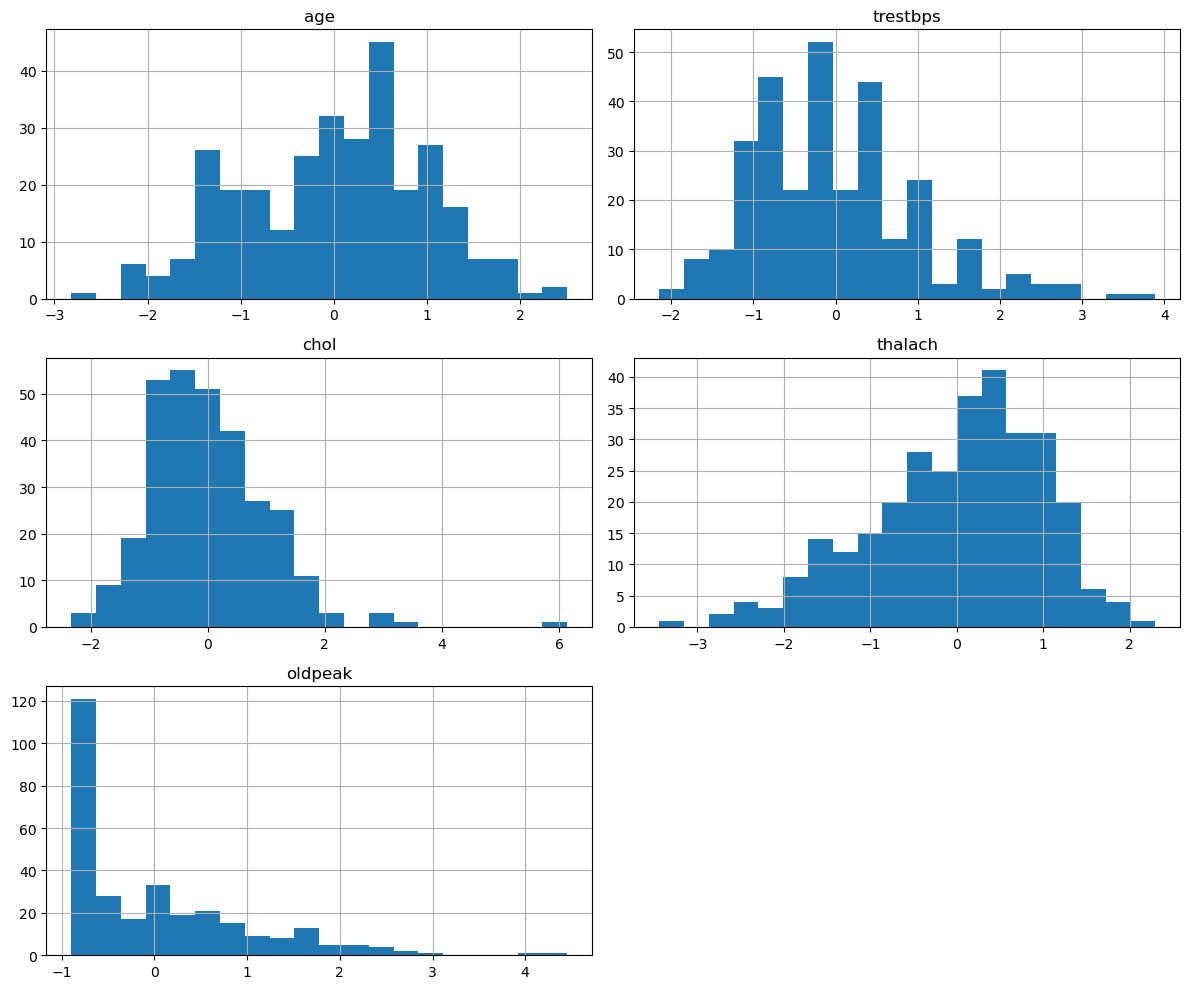

In [115]:
# Distributions of the Numerical Variables
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

Most of the distributions of numerical variables are imbalanced(either left- or right-skewed) except 'age'.

In [116]:
# Distributions of categorical varaibles, here we look at num
df['num'].value_counts()

num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

The num variable scores are unbalanced, with notably fewer patients diagnosed at 1, 2, 3 and 4 compared to
0(more patients declared absence of heart disease than presence).

\newpage

In [117]:
(4)
df['num'] = pd.Categorical((df['num'] != 0).astype(int))
df['num'] = pd.Categorical(df['num'])

In [118]:
df['num'].value_counts()

num
0    164
1    139
Name: count, dtype: int64

\newpage

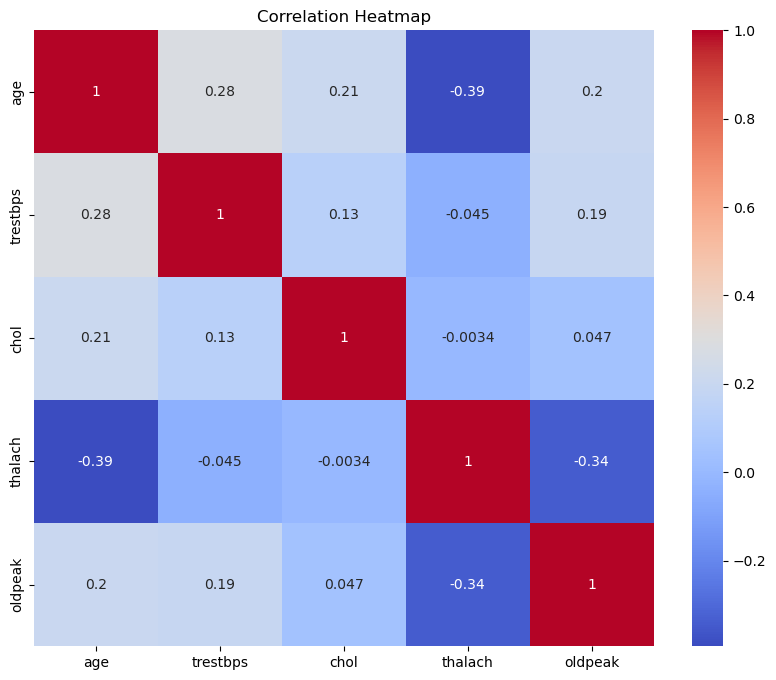

In [119]:
(5)
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The variables thalach and oldpeak have a moderate negative relationship(-0.34). This means when a patient’s maximum heart rate (thalach) is low, their ST depression (oldpeak) is usually higher. These two features show different parts of a person’s heart condition. Because of this, they are useful to keep in the model (feature selection). Their relationship can also help if we use a method like PCA to combine features (feature extraction).

The variables thalach and age also have a moderate negative relationship(-0.39), suggesting that older patients tend to have lower maximum heart rates. Since low thalach is often associated with higher heart disease risk, this variable is potentially valuable for prediction too.

\newpage

In [120]:
(6)
df_cleaned = df.dropna()
num_obs_after_dropna = len(df_cleaned)
print(f"Number of observations after dropping missing values: {num_obs_after_dropna}")


Number of observations after dropping missing values: 297


In [121]:
# predictors
X = df.drop(columns=['num'])
#response
y = df.num

\newpage

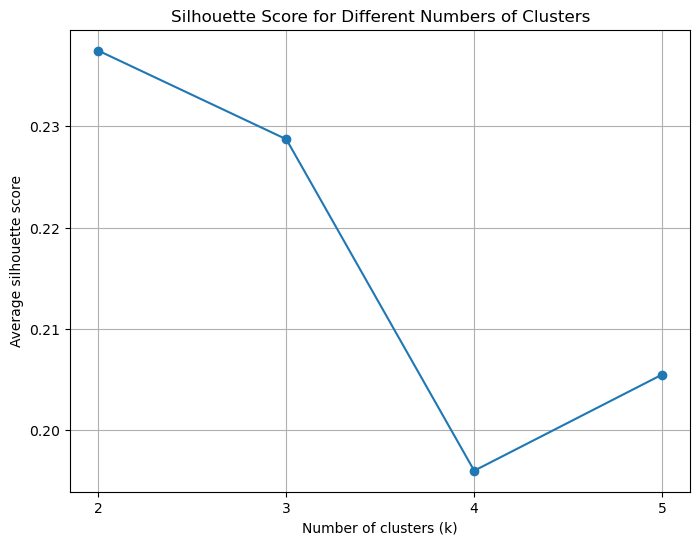

In [122]:
(7)
# We got numerical variables and stored them into num_cols in question 2.
X_num = X[num_cols].copy()
X_num_cleaned = X_num.dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num_cleaned)
range_n_clusters = range(2, 6)
silhouette_scores = []
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

plt.figure(figsize=(8, 6))
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Average silhouette score")
plt.title("Silhouette Score for Different Numbers of Clusters")
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

k=2 has the highest silhouette score, indicating a better cluster separation.

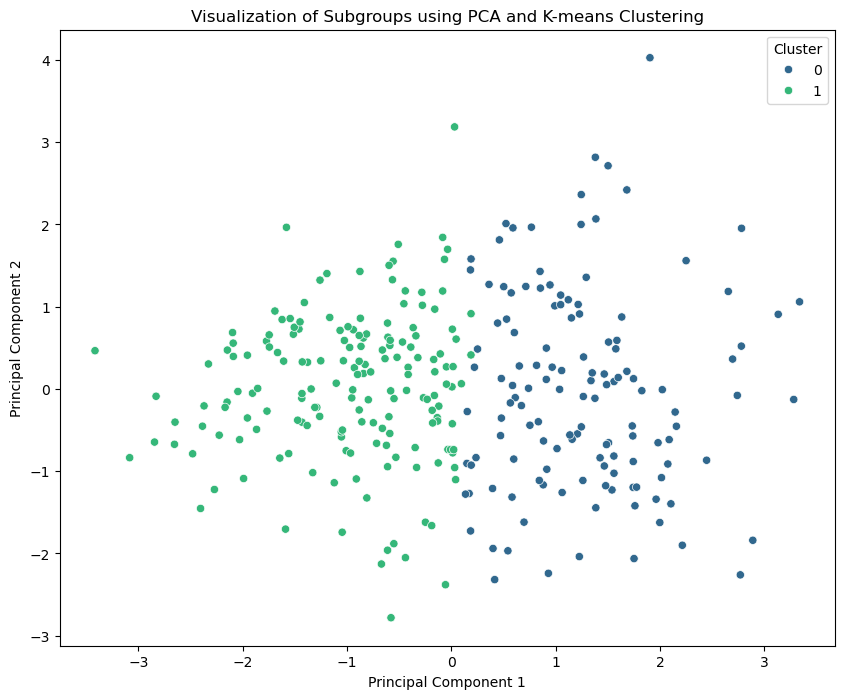

In [123]:
n_clusters_optimal = 2
kmeans_optimal = KMeans(n_clusters=n_clusters_optimal, n_init=10, random_state=42)
clusters = kmeans_optimal.fit_predict(X_scaled)
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=principal_components, columns=['Principal Component 1', 'Principal Component 2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='viridis')
plt.title('Visualization of Subgroups using PCA and K-means Clustering')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()

\newpage

In [124]:
(8)
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.3,
random_state=1,
)

\newpage

(9)  
I chose a Decision Tree as one of the classifiers because:    
It is inherently interpretable and their tree-like structure, with nodes representing features and branches representing decisions based on feature values, makes understanding the predictions clearer. Following the path from the root to a leaf node, I can understand the specific conditions that lead to a particular classification (presence or absence of heart disease). It also handles both numerical and categorical features without requiring scaling or encoding.  

As the second classifier, I selected a Random Forest, which is not as directly interpretable as a single Decision Tree. It is an ensemble method that improves prediction accuracy and reduces overfitting compared to a single tree. It also can measure feature importance, which gives insight into the most useful predictors.
This can be valuable for classifying patients with and without heart disease.



\newpage

(10)  
(I) Accuracy  
I use the accuracy to measure the overall correctness of my classifier. It shows the proportion of correctly classified instances out of the all the instances in the test set.  
Technical Details:  
Firstly, train the DecisionTreeClassifier (dt_best) using the training features (X_train) and training labels (y_train). After the model is trained, use dt_best.score(X_test, y_test) to calculate the accuracy of this trained model on the unseen test data (X_test, y_test).
  
(II) Sensitivity  
I use Sensitivity to measure the ability of the classifier to correctly identify all the actual positive instances.  
Technical Details:  
I will use the recall_score function from sklearn.metrics. After predicting labels on the test set with each trained classifier, I compare them to the true labels to calculate sensitivity.


\newpage

In [125]:
(11)
# Decision Tree
depth_range = range(1, 20)
cv_scores = []
for k in depth_range:
    dt = DecisionTreeClassifier(
        criterion='gini',
        random_state=1, 
        max_depth=k
        )
    

    cv_scores_k = cross_val_score(
        dt,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'  
    )
    
    cv_scores.append(np.mean(cv_scores_k))

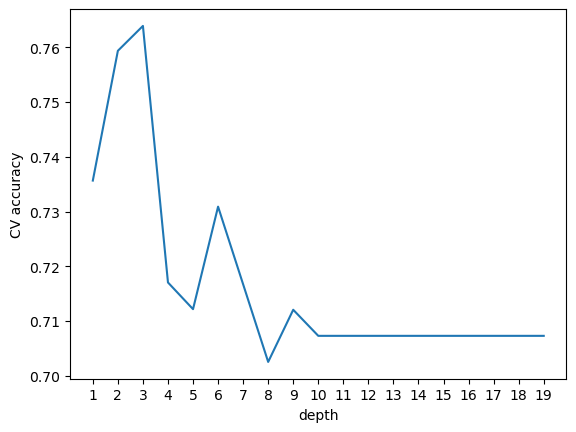

In [126]:
plt.plot(depth_range, cv_scores)
plt.xlabel('depth')
plt.ylabel('CV accuracy')
plt.xticks(range(1,20))
plt.show()

Identify the optimal tuning parameter for the Decision Tree:  
Based on the cross-validation results, the best-performing classification tree has a max depth of 3.

In [127]:
dt_best = DecisionTreeClassifier(
    max_depth = 3, 
    random_state=1
    ) 
dt_best.fit(X_train, y_train)
test_accuracy = dt_best.score(X_test, y_test)
print("Test accuracy:", round(test_accuracy,2))

Test accuracy: 0.78


The test accuracy of the classifier(Decision Tree) is 78%.

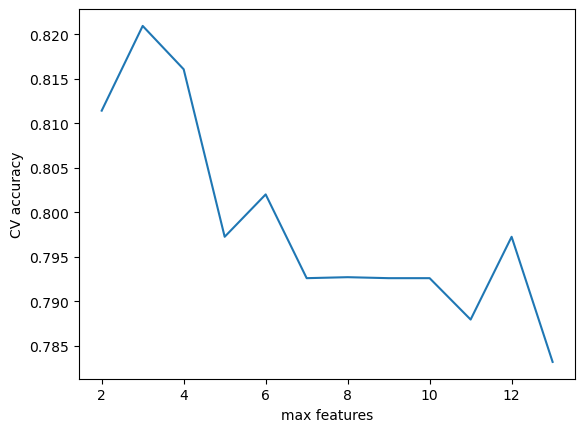

In [128]:
# Random Forest
scores_cv = []
m_feas = range(2, X_train.shape[1] + 1)

for m_fea in m_feas:
    scores = cross_val_score(
        RandomForestClassifier(
            n_estimators=200,
            max_features=m_fea,
            random_state=1,
            bootstrap=True,
            oob_score=False
        ),
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    scores_cv.append(scores.mean())

plt.plot(m_feas, scores_cv)
plt.xlabel('max features')
plt.ylabel('CV accuracy')
plt.show()

Identify the optimal tuning parameter for the Random Forest:  
Based on the cross-validation results, the best-performing classification tree has a max depth of 3.

In [129]:
rf_best = RandomForestClassifier(
    n_estimators=200,           
    max_features=3,
    random_state=1
)

# Train on full training set
rf_best.fit(X_train, y_train)

# Evaluate on test set
test_accuracy_rf = rf_best.score(X_test, y_test)
print("Test accuracy:", round(test_accuracy_rf, 2))

Test accuracy: 0.85


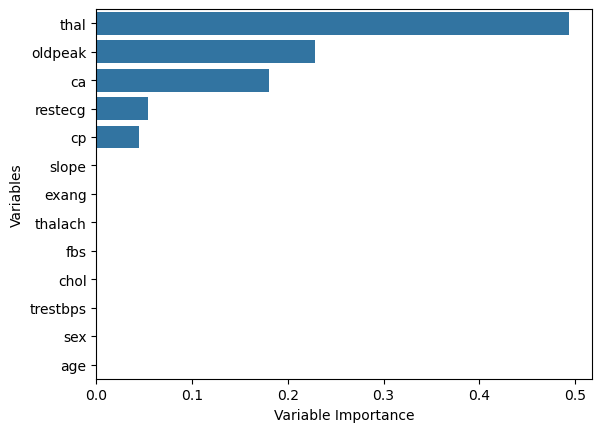

In [137]:
(12)
# We chose the Decision Tree classifier
fea_imp = dt_best.feature_importances_
sorted_indices = fea_imp.argsort()[::-1]
sorted_feature_names = X_train.columns[sorted_indices]
sorted_importances = fea_imp[sorted_indices]
sns.barplot(x = sorted_importances, y = sorted_feature_names)
plt.xlabel('Variable Importance')
plt.ylabel('Variables')
plt.show()

From the plot above we decided the three most important variables in predicting the presence of heart diseases in patients are thal, oldpeak and ca.

In [131]:
# Train this third classifier on the training set and identify optimal tuning parameters
top_k = 3
top_k_features = sorted_feature_names[:top_k]
X_train_topk = X_train[top_k_features]
X_test_topk = X_test[top_k_features]
depth_range = range(1, 20)
cv_scores_topk = []

for k in depth_range:
    dt = DecisionTreeClassifier(max_depth=k, random_state=1)
    scores = cross_val_score(dt, X_train_topk, y_train, cv=5, scoring='accuracy')
    cv_scores_topk.append(scores.mean())

best_depth = depth_range[np.argmax(cv_scores_topk)]
print(best_depth)

3


We identify the optimal tuning parameter for the third classifier: 3

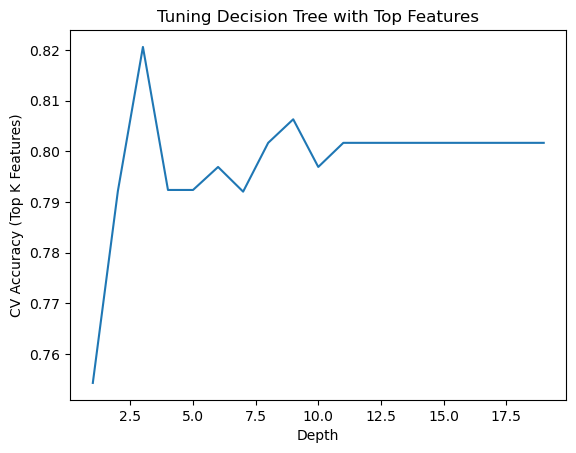

Test Accuracy with top 3 features: 0.76


In [132]:
plt.plot(depth_range, cv_scores_topk)
plt.xlabel('Depth')
plt.ylabel('CV Accuracy (Top K Features)')
plt.title('Tuning Decision Tree with Top Features')
plt.show()
best_depth = depth_range[np.argmax(cv_scores_topk)]
dt_topk = DecisionTreeClassifier(max_depth=best_depth, random_state=1)
dt_topk.fit(X_train_topk, y_train)

test_accuracy_topk = dt_topk.score(X_test_topk, y_test)
print("Test Accuracy with top", top_k, "features:", round(test_accuracy_topk, 2))

\newpage

In [133]:
(13)
# (I) Accuracy
# From Question 11 and 12 we got the test accuracy for all the classifiers
print("The test accuracy for the Decision Tree classifier:", round(test_accuracy,2))
print("The test accuracy for the Random Forest classifier:", round(test_accuracy_rf,2))
print("The test accuracy for the third classifier:", round(test_accuracy_topk,2))

The test accuracy for the Decision Tree classifier: 0.78
The test accuracy for the Random Forest classifier: 0.85
The test accuracy for the third classifier: 0.76


In [134]:
# (II) Sensitivity  
# Classifier 1
y_pred = dt_best.predict(X_test)
sensitivity1 = recall_score(y_test, y_pred)
print(f"Sensitivity for the first classifier: {sensitivity1:.2f}")

# Classifier 2
y_pred = rf_best.predict(X_test)
sensitivity2 = recall_score(y_test, y_pred)
print(f"Sensitivity for the second classifier: {sensitivity2:.2f}")

# Classifier 3
X_test_topk = X_test[top_k_features]
y_pred = dt_topk.predict(X_test_topk)
sensitivity3 = recall_score(y_test, y_pred)
print(f"Sensitivity for the third classifier: {sensitivity3:.2f}")


Sensitivity for the first classifier: 0.67
Sensitivity for the second classifier: 0.79
Sensitivity for the third classifier: 0.71


Findings:  

The Random Forest classifier achieves the highest accuracy (0.85) and highest sensitivity (0.79). This suggests that not only does it make the fewest total mistakes, but it's also the most effective at detecting true positive cases, making it the most reliable model overall.

Although the third classifier had lower accuracy (0.76) than the Decision Tree (0.78), its improved sensitivity (0.71 vs 0.67) shows it captures the positive class better, which may be more important in sensitive health-related predictions.

Impact of Feature Selection:   
  
Using feature selection helped the third classifier focus on the most important variables, which slightly improved its ability to detect positive cases. However, it didn’t boost the overall accuracy—so while it might help in situations where catching positives really matters, it doesn’t always make the model better overall.

\newpage

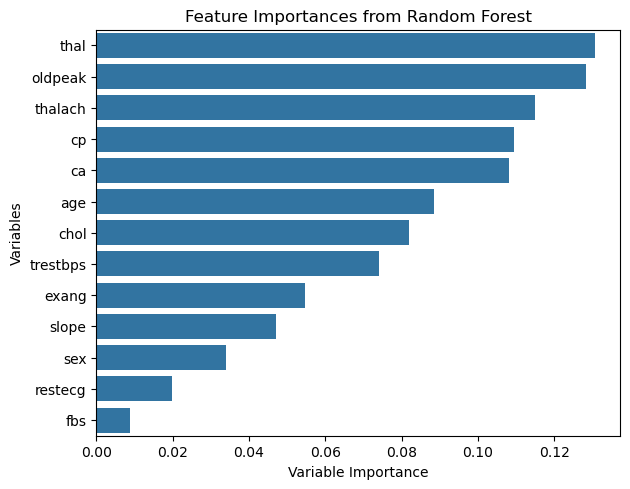

In [138]:
(14)
# The Random Forest model is the best interpretable model froom question 13:
fea_imp = rf_best.feature_importances_
sorted_indices = fea_imp.argsort()[::-1]
sorted_feature_names = X_train.columns[sorted_indices]
sorted_importances = fea_imp[sorted_indices]

sns.barplot(x=sorted_importances, y=sorted_feature_names)
plt.title("Feature Importances from Random Forest")
plt.tight_layout()
plt.xlabel('Variable Importance')
plt.ylabel('Variables')
plt.show()


Analysis and Interpretations:  
‘Thal’ (maximum heart rate achieved) is the most important feature, indicating that higher or abnormal heart rate responses during exercise are strong indicators of heart disease in this dataset.

‘Oldpeak’(ST depression induced by exercise relative to rest) is the second most important predictor. This feature is highly indicative of cardiac risk, making it highly important in the context of this classification challenge.

\newpage

In [136]:
(15)
# Since Random Forest was my best performer in Q13, we’ll train one Random Forest for each cluster.
X_with_clusters = X.copy()
X_with_clusters['Cluster'] = clusters
y_with_clusters = y[X_with_clusters.index]

accuracies = []
sensitivities = []

for cluster_id in range(n_clusters_optimal):
    X_cluster = X_with_clusters[X_with_clusters['Cluster'] == cluster_id].drop(columns='Cluster')
    y_cluster = y_with_clusters[X_with_clusters['Cluster'] == cluster_id]
    
    X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cluster, y_cluster, test_size=0.3, random_state=42)

    rf_c = RandomForestClassifier(random_state=42)
    rf_c.fit(X_train_c, y_train_c)
    y_pred_c = rf_c.predict(X_test_c)
    
    acc = accuracy_score(y_test_c, y_pred_c)
    rec = recall_score(y_test_c, y_pred_c)
    
    accuracies.append(acc)
    sensitivities.append(rec)

print(f"Average accuracy of sub-group classifiers: {round(np.mean(accuracies), 2)}")
print(f"Average sensitivity of sub-group classifiers: {round(np.mean(sensitivities), 2)}")


Average accuracy of sub-group classifiers: 0.87
Average sensitivity of sub-group classifiers: 0.86


The average performance of these subgroup-specific models was 87% accuracy and 86% sensitivity, compared to 85% and 79% from the general model in Question 13.
This suggests that modeling each cluster individually can capture more nuanced patterns, slightly improving performance.

\newpage


(16)  
Zeel Patel: Question 1-6, 8  
Jennifer Xie: Question 7, 9-15

\newpage

(17)
The link to the public github repository:  [Stats3da3_assign6](https://github.com/zeelp7/Stats3da3_assign6.git)

## References  
-Janosi, A., Steinbrunn, W., Pfisterer, M., & Detrano, R. (1989). Heart Disease [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P4X.   
-[linear-regression-application-subgroup](https://avenue.cllmcmaster.ca/d2l/le/content/677151/viewContent/5071695/View)    
-[ensemble-application](https://avenue.cllmcmaster.ca/d2l/le/content/677151/viewContent/5053427/View)    
  
